In [1]:
# read the data
import matplotlib.pyplot as plt
import numpy as np
#import pandas as pd
import matplotlib

import mne
import os
from mne.preprocessing import ICA
import ast

In [2]:
## Some of the common function 
def identify_bad_channels(data, threshold=80e-6):
    """
    Identify bad channels based on amplitude difference exceeding the threshold.
    
    :param data: 3D array of shape (n_epochs, n_channels, n_times)
    :param threshold: Amplitude difference threshold in Volts (default: 80 microvolts)
    :return: List of bad channel indices
    """
    amplitude_diff = np.ptp(data, axis=2)  # peak-to-peak amplitude for each epoch and channel
    bad_channels = np.where(np.any(amplitude_diff > threshold, axis=0))[0]
    return bad_channels.tolist()


def remove_epochs_with_bad_mmn_channels(epochs, mmn_channels, amplitude_threshold=80e-6):
    """
    Remove epochs where MMN-related channels exceed the amplitude threshold.
    
    :param epochs: mne.Epochs object
    :param mmn_channels: List of MMN channel names
    :param amplitude_threshold: Amplitude difference threshold in Volts (default: 80 microvolts)
    :return: mne.Epochs object with bad epochs removed
    """
    data = epochs.get_data()
    
    
    bad_mmn_epochs = []
    for epoch_idx in range(len(epochs)):
        epoch_data = data[epoch_idx]
        epoch_bad_channels = identify_bad_channels(epoch_data[np.newaxis, :, :], amplitude_threshold)
        
        for ch_idx in epoch_bad_channels:
            ch_name = epochs.ch_names[ch_idx]
            if any(mmn_ch in ch_name for mmn_ch in mmn_channels):
                bad_mmn_epochs.append(epoch_idx)
                break
    
    good_epochs = np.setdiff1d(np.arange(len(epochs)), bad_mmn_epochs)
    return epochs[good_epochs]


# Concate all Epochs then average  for event 14,15 

### Block 1 MMN calculation

In [ ]:
data_folder = r"D:\Work_data\Notification_evoked_response\Data_at_IITD/"
subjects = os.listdir(data_folder)
data_type = "EEG"
 # it is useful to scroll eeg data 
# Create an empty list to hold epochs from all subjects
#B1_sta_all_epochs_list =[]
#B1_devi_all_epochs_list = []
B1_all_epochs_list =[]
B2_all_epochs_list =[]
for sub in os.listdir(data_folder):
    path = os.path.join(data_folder,sub,data_type)
    
    for eeg in os.listdir(path):
        if eeg[-5:] == ".vhdr":
           
            raw = mne.io.read_raw_brainvision(os.path.join(path,eeg), preload=True)
            raw = mne.add_reference_channels(raw, ref_channels=["Cz"])
            raw.set_montage("easycap-M1")
            #raw.plot(scalings=dict(eeg=40e-6),clipping='transparent',duration=30.0, start=690.0, n_channels=63,color = "Blue",event_color ='black',show_options=True )
            # Now re-reference the data :-n average reference 
            #raw.set_eeg_reference('average')
            raw.set_eeg_reference(ref_channels=['TP9', 'TP10'])
            # filter 
            raw.filter(l_freq=0.1,h_freq=30)
            events,event_dict = mne.events_from_annotations(raw)
            epochs_with_eog = mne.Epochs(raw, events, event_id=[14,15,24,25] ,tmin=-0.300, tmax=0.700,
                    baseline=(None, 0), reject_by_annotation=False,
                    preload=True)
            print(f"Original number of epochs in Block 1  {len(epochs_with_eog['14','15'])} and in Block 2 {len(epochs_with_eog['24','25'])}")
            
            # EOG detection and epoch rejection
            eog_channels = ['Fp1', 'Fp2', 'F7', 'F8',"AF7",'AF8']  # Adjust these to match your channel names
            
            eog_events = mne.preprocessing.find_eog_events(raw,ch_name=eog_channels)
            onsets = eog_events[:, 0] / raw.info["sfreq"] - 0.25
            durations = [0.5] * len(eog_events)
            descriptions = ["bad blink"] * len(eog_events)
            blink_annot = mne.Annotations(
                onsets, durations, descriptions, orig_time=raw.info["meas_date"]
                )
            raw.set_annotations(blink_annot)
            #raw.plot(events =events , scalings=dict(eeg=40e-6),clipping='transparent',duration=30.0, start=690.0, n_channels=63,color = "Blue" )
            # Create Epochs
            epochs = mne.Epochs(raw, events, event_id=[14,15,24,25] ,tmin=-0.300, tmax=0.700,
                    baseline=(None, 0), reject_by_annotation=True,
                    preload=True)
            
            print(f"After Eog rejection, number of epochs in Block 1  {len(epochs['14','15'])} and in Block 2 {len(epochs['24','25'])}")
            # Define your MMN channels
            mmn_channels = [ 'Fz', 'Cz','Pz']  # Example MMN channels, adjust as needed
            # Remove epochs with bad MMN channels
            cleaned_epochs = remove_epochs_with_bad_mmn_channels(epochs, mmn_channels)
            
            print(f"After Bad epoch rejection,  number of epochs in Block 1  {len(cleaned_epochs['14','15'])} and in Block 2 {len(cleaned_epochs['24','25'])}")
            # Append the subject's epochs to the list
            """B1_sta_all_epochs_list.append(cleaned_epochs['14'])
            B1_devi_all_epochs_list.append(cleaned_epochs['15']) """
            B1_all_epochs_list.append(cleaned_epochs['14','15'])
            #B2_all_epochs_list.append(cleaned_epochs['24','25'])





B1_all_epochs = mne.concatenate_epochs(B1_all_epochs_list)


print(f"After Bad epoch rejection,  number of epochs in Block 1 standard {len(B1_all_epochs['14'])} and deviant {len(B1_all_epochs['15'])}")
B1_devi_eps = B1_all_epochs['15'].average()
B1_sta_eps = B1_all_epochs["14"].average()
B1_MMN_erp = mne.combine_evoked([ B1_devi_eps,B1_sta_eps], weights=[1,-1])
evokeds = dict(B1_MMN_erp =B1_MMN_erp, B1_devi_eps= B1_devi_eps,B1_sta_eps=B1_sta_eps)  
#picks = [n for n in range(1, 5)]
picks= ['F3', 'Fz', 'F4',]
mne.viz.plot_compare_evokeds(evokeds, picks=picks,title  =  "Grand BLock1 avaerage 'F3', 'Fz', 'F4'", combine="mean")
"""After Bad epoch rejection,  number of epochs in Block 1 standard 14230 and deviant 2861"""


### Block 2 MMN calculation 

In [ ]:
del B1_all_epochs
del B1_all_epochs_list


data_folder = r"D:\Work_data\Notification_evoked_response\Data_at_IITD/"
subjects = os.listdir(data_folder)
data_type = "EEG"
 # it is useful to scroll eeg data 
# Create an empty list to hold epochs from all subjects
#B1_sta_all_epochs_list =[]
#B1_devi_all_epochs_list = []
#B1_all_epochs_list =[]
B2_all_epochs_list =[]
for sub in os.listdir(data_folder):
    path = os.path.join(data_folder,sub,data_type)
    
    for eeg in os.listdir(path):
        if eeg[-5:] == ".vhdr":
           
            raw = mne.io.read_raw_brainvision(os.path.join(path,eeg), preload=True)
            raw = mne.add_reference_channels(raw, ref_channels=["Cz"])
            raw.set_montage("easycap-M1")
            #raw.plot(scalings=dict(eeg=40e-6),clipping='transparent',duration=30.0, start=690.0, n_channels=63,color = "Blue",event_color ='black',show_options=True )
            # Now re-reference the data :-n average reference 
            #raw.set_eeg_reference('average')
            
            raw.set_eeg_reference(ref_channels=['TP9', 'TP10'])
            # filter 
            raw.filter(l_freq=0.1,h_freq=30)
            events,event_dict = mne.events_from_annotations(raw)
            epochs_with_eog = mne.Epochs(raw, events, event_id=[14,15,24,25] ,tmin=-0.300, tmax=0.700,
                    baseline=(None, 0), reject_by_annotation=False,
                    preload=True)
            print(f"Original number of epochs in Block 1  {len(epochs_with_eog['14','15'])} and in Block 2 {len(epochs_with_eog['24','25'])}")
            
            # EOG detection and epoch rejection
            eog_channels = ['Fp1', 'Fp2', 'F7', 'F8',"AF7",'AF8']  # Adjust these to match your channel names
            
            eog_events = mne.preprocessing.find_eog_events(raw,ch_name=eog_channels)
            onsets = eog_events[:, 0] / raw.info["sfreq"] - 0.25
            durations = [0.5] * len(eog_events)
            descriptions = ["bad blink"] * len(eog_events)
            blink_annot = mne.Annotations(
                onsets, durations, descriptions, orig_time=raw.info["meas_date"]
                )
            raw.set_annotations(blink_annot)
            #raw.plot(events =events , scalings=dict(eeg=40e-6),clipping='transparent',duration=30.0, start=690.0, n_channels=63,color = "Blue" )
            # Create Epochs
            epochs = mne.Epochs(raw, events, event_id=[14,15,24,25] ,tmin=-0.300, tmax=0.700,
                    baseline=(None, 0), reject_by_annotation=True,
                    preload=True)
            
            print(f"After Eog rejection, number of epochs in Block 1  {len(epochs['14','15'])} and in Block 2 {len(epochs['24','25'])}")
            # Define your MMN channels
            mmn_channels = ['Fz', 'Cz','Pz'  ]  # Example MMN channels, adjust as needed
            # Remove epochs with bad MMN channels
            cleaned_epochs = remove_epochs_with_bad_mmn_channels(epochs, mmn_channels)
            
            print(f"After Bad epoch rejection,  number of epochs in Block 1  {len(cleaned_epochs['14','15'])} and in Block 2 {len(cleaned_epochs['24','25'])}")
            # Append the subject's epochs to the list
            """B1_sta_all_epochs_list.append(cleaned_epochs['14'])
            B1_devi_all_epochs_list.append(cleaned_epochs['15']) """
            #B1_all_epochs_list.append(cleaned_epochs['14','15'])
            B2_all_epochs_list.append(cleaned_epochs['24','25'])





B2_all_epochs = mne.concatenate_epochs(B2_all_epochs_list)


print(f"After Bad epoch rejection,  number of epochs in Block 2 standard {len(B2_all_epochs['24'])} and deviant {len(B2_all_epochs['25'])}")
B2_devi_eps = B2_all_epochs['25'].average()
B2_sta_eps = B2_all_epochs["24"].average()
B2_MMN_erp = mne.combine_evoked([ B2_devi_eps,B1_sta_eps], weights=[1,-1])
evokeds = dict(B2_MMN_erp =B2_MMN_erp, B2_devi_eps= B2_devi_eps,B2_sta_eps=B2_sta_eps)  
#picks = [n for n in range(1, 5)]
picks= ['F3', 'Fz', 'F4',]
mne.viz.plot_compare_evokeds(evokeds, picks=picks,title  =  "Grand BLock2 avaerage 'F3', 'Fz', 'F4'", combine="mean")
"""After Bad epoch rejection,  number of epochs in Block 2 standard 13719 and deviant 2816"""


In [ ]:

del B2_all_epochs
del B2_all_epochs_list

MMN_evokeds = dict(B1_MMN_erp =B1_MMN_erp, 
                   B1_devi_eps= B1_devi_eps,
                   B1_sta_eps=B1_sta_eps,
                   B2_MMN_erp =B2_MMN_erp, 
                   B2_devi_eps= B2_devi_eps,
                   B2_sta_eps=B2_sta_eps)  
mne.viz.plot_compare_evokeds(MMN_evokeds, picks=picks, title  = "Grand  avaerage 'F3', 'Fz', 'F4'",combine="mean")

### Personailed audio related ERP

In [6]:
def get_latency_amp(evokeds,tmin, tmax,channels = picks):
    peak_data = {}
    for name, evoked in evokeds.items():
        evoked_fz = evoked.copy().pick(picks)
        # Retrieve the latency (time), amplitude, and channel where the peak occurs
        peak_channel, peak_time, peak_amplitude,  = evoked_fz.get_peak(ch_type='eeg', tmin=tmin, tmax=tmax, mode='neg', return_amplitude=True)
        peak_data[name] = {
            'Channel': peak_channel,  # channel where peak occurs
            'Latency (s)': peak_time,  # latency of peak
            'Amplitude (µV)': peak_amplitude  # amplitude of peak
            }
    return peak_data

def get_latency_amp_each_chn(evokeds,tmin, tmax,channels):
    peak_data = {}
    for name, evoked in evokeds.items():
        peak_data[name] = {}
        for ch in channels:
            evoked_fz = evoked.copy()
            evoked_fz =evoked_fz.pick([str(ch)])
            # Retrieve the latency (time), amplitude, and channel where the peak occurs
            try:
                peak_channel, peak_time_p, peak_amplitude_p,  = evoked_fz.get_peak(ch_type='eeg', tmin=tmin, tmax=tmax, mode='pos', return_amplitude=True)
                peak_data[name].update({str(ch) + ' +(Latency (s),Amplitude (µV))': str((peak_time_p, round( peak_amplitude_p*1e6,3)))})
            except:
                (peak_time_p, peak_amplitude_p)= ("Na", 'Na')
                peak_data[name].update({str(ch) + ' +(Latency (s),Amplitude (µV))': str((peak_time_p, peak_amplitude_p))}) 
            try:
                peak_channel, peak_time_n, peak_amplitude_n,  = evoked_fz.get_peak(ch_type='eeg', tmin=tmin, tmax=tmax, mode='neg', return_amplitude=True)
                peak_data[name].update({str(ch) + '- (Latency (s),Amplitude (µV))': str((peak_time_n, round(peak_amplitude_n*1e6,3)))})
            except:
                (peak_time_n, peak_amplitude_n)= ("Na", 'Na')
                peak_data[name].update({str(ch) + '- (Latency (s),Amplitude (µV))': str((peak_time_n, peak_amplitude_n))}) 
            
    return peak_data


# Plot positive peak 
def plot_pos_peak(str_tuple,axes):
    pos_peak = ast.literal_eval(str_tuple)
    axes.scatter(pos_peak[0],pos_peak[1], color='black',marker = "*",s=100)
    axes.text(pos_peak[0],pos_peak[1]+.2, f'({pos_peak[0]:.2f},{pos_peak[1]:.3f})', color='black', fontsize=18, ha='center')
# Plot negative  peak 
def plot_neg_peak(str_tuple,axes):
    neg_peak = ast.literal_eval(str_tuple)
    axes.scatter(neg_peak[0],neg_peak[1], color='black',marker = "*",s=100)
    axes.text(neg_peak[0],neg_peak[1]-.2, f'({neg_peak[0]:.2f},{neg_peak[1]:.3f})', color='black', fontsize=18, ha='center')

latency_amps = []

In [7]:
# Personailzed audio related ERP 
Personalized_MMN_erp = mne.combine_evoked([ B1_MMN_erp,B2_MMN_erp], weights=[1,-1])
picks  = ["Fz","Cz","Pz"]

{'B1 MMN': {'Fz +(Latency (s),Amplitude (µV))': '(0.369, 0.811)', 'Fz- (Latency (s),Amplitude (µV))': '(0.26, -3.851)', 'Cz +(Latency (s),Amplitude (µV))': '(0.35, 1.696)', 'Cz- (Latency (s),Amplitude (µV))': '(0.259, -3.091)', 'Pz +(Latency (s),Amplitude (µV))': '(0.348, 0.989)', 'Pz- (Latency (s),Amplitude (µV))': '(0.256, -1.587)'}, 'B2 MMN': {'Fz +(Latency (s),Amplitude (µV))': '(0.381, 1.673)', 'Fz- (Latency (s),Amplitude (µV))': '(0.29, -3.312)', 'Cz +(Latency (s),Amplitude (µV))': '(0.377, 1.789)', 'Cz- (Latency (s),Amplitude (µV))': '(0.293, -2.505)', 'Pz +(Latency (s),Amplitude (µV))': '(0.367, 0.973)', 'Pz- (Latency (s),Amplitude (µV))': '(0.29, -1.292)'}, 'Pers. sign. ERP': {'Fz +(Latency (s),Amplitude (µV))': '(0.314, 2.209)', 'Fz- (Latency (s),Amplitude (µV))': '(0.253, -1.282)', 'Cz +(Latency (s),Amplitude (µV))': '(0.316, 2.646)', 'Cz- (Latency (s),Amplitude (µV))': '(0.249, -1.293)', 'Pz +(Latency (s),Amplitude (µV))': '(0.317, 1.441)', 'Pz- (Latency (s),Amplitude (µV))

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21180\694927130.py:31: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],


combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21180\694927130.py:34: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21180\694927130.py:37: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],


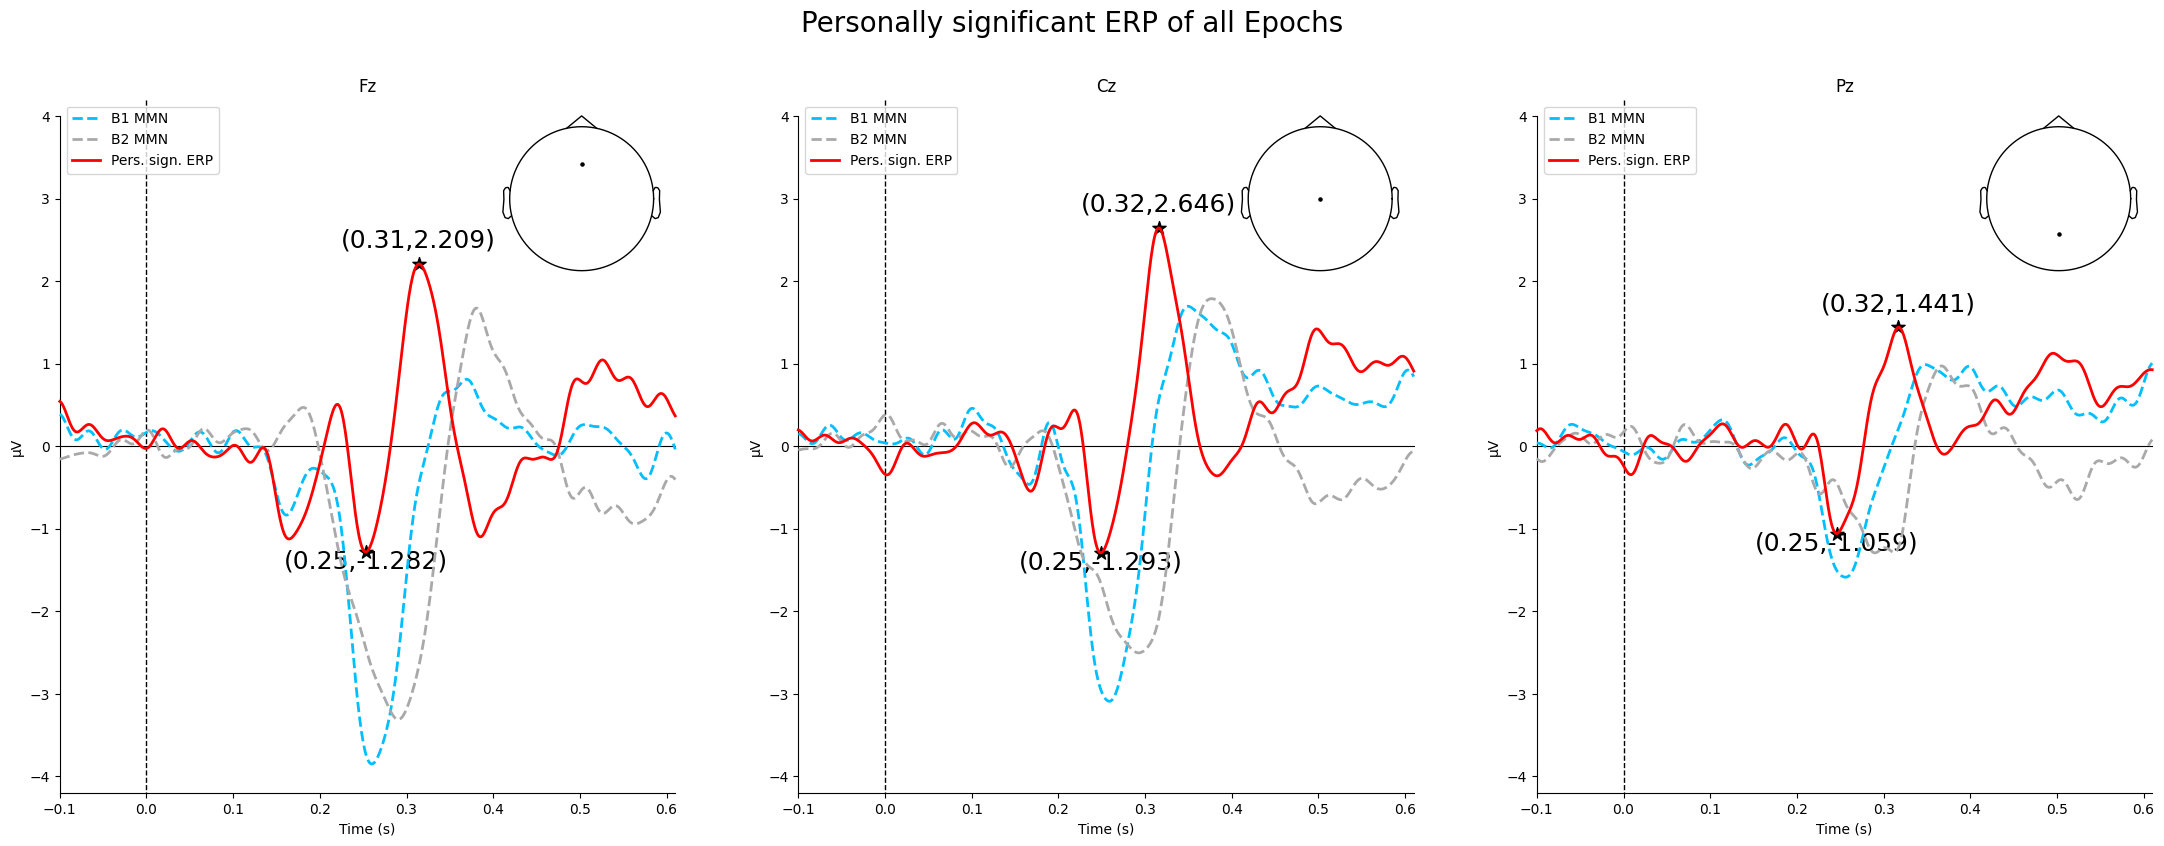

In [8]:
# PS ERp 

evokeds = {'B1 MMN': B1_MMN_erp,
           'B2 MMN': B2_MMN_erp,
           "Pers. sign. ERP" : Personalized_MMN_erp,
           }
# Define the start and end time for the window
start_time = -0.1  # Start of time window in seconds
end_time = 0.61    # End of time window in seconds

# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

laten_data = get_latency_amp_each_chn(evokeds_subset,tmin=.2,tmax =.4, channels=picks)
print(laten_data )
latency_amps.append(laten_data)

# Plot the evoked responses
fig,axs = plt.subplots(1,3,figsize=(27, 9))  # Create a figure and axis


stylesdict ={'B1 MMN': {"linewidth": 2,"linestyle":'--'},
             'B2 MMN': {"linewidth": 2,"linestyle":'--'},
             'Pers. sign. ERP': {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[0],ylim = dict(eeg=[-4.2, 4.2]),
                                   truncate_xaxis=False,show = False)
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[1],ylim = dict(eeg=[-4.2, 4.2]),
                                   truncate_xaxis=False,show= False)
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[2],ylim = dict(eeg=[-4.2, 4.2]),
                                   truncate_xaxis=False,show= False)

plot_pos_peak(laten_data["Pers. sign. ERP"]['Fz +(Latency (s),Amplitude (µV))'],axs[0])
plot_neg_peak(laten_data["Pers. sign. ERP"]['Fz- (Latency (s),Amplitude (µV))'],axs[0])
plot_pos_peak(laten_data["Pers. sign. ERP"]['Cz +(Latency (s),Amplitude (µV))'],axs[1])
plot_neg_peak(laten_data["Pers. sign. ERP"]['Cz- (Latency (s),Amplitude (µV))'],axs[1])
plot_pos_peak(laten_data["Pers. sign. ERP"]['Pz +(Latency (s),Amplitude (µV))'],axs[2])
plot_neg_peak(laten_data["Pers. sign. ERP"]['Pz- (Latency (s),Amplitude (µV))'],axs[2])
# Add an overall title for the whole plot
fig.suptitle('Personally significant ERP of all Epochs', fontsize=20)
plt.rcParams.update({
    'xtick.labelsize': 20,  # X-axis tick labels font size
    'ytick.labelsize': 20,  # Y-axis tick labels font size
    'axes.labelsize': 20,   # Axis label font size
    'axes.titlesize': 20,   # Title font size 
    'legend.fontsize': 20,   # Legend font size
})
plt.show()

### BLock 1 MMN

{'Pers. deviant': {'Fz +(Latency (s),Amplitude (µV))': '(0.316, 0.015)', 'Fz- (Latency (s),Amplitude (µV))': '(0.242, -4.184)', 'Cz +(Latency (s),Amplitude (µV))': '(0.318, 1.254)', 'Cz- (Latency (s),Amplitude (µV))': '(0.238, -3.685)', 'Pz +(Latency (s),Amplitude (µV))': '(0.325, 0.462)', 'Pz- (Latency (s),Amplitude (µV))': '(0.239, -2.076)'}, 'non. sign. standard': {'Fz +(Latency (s),Amplitude (µV))': '(0.284, 1.669)', 'Fz- (Latency (s),Amplitude (µV))': '(0.221, -2.512)', 'Cz +(Latency (s),Amplitude (µV))': '(0.285, 1.617)', 'Cz- (Latency (s),Amplitude (µV))': '(0.221, -2.216)', 'Pz +(Latency (s),Amplitude (µV))': '(0.287, 0.568)', 'Pz- (Latency (s),Amplitude (µV))': '(0.222, -1.139)'}, 'B1 MMN': {'Fz +(Latency (s),Amplitude (µV))': '(0.369, 0.811)', 'Fz- (Latency (s),Amplitude (µV))': '(0.26, -3.851)', 'Cz +(Latency (s),Amplitude (µV))': '(0.35, 1.696)', 'Cz- (Latency (s),Amplitude (µV))': '(0.259, -3.091)', 'Pz +(Latency (s),Amplitude (µV))': '(0.348, 0.989)', 'Pz- (Latency (s),Am

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21180\4031759625.py:36: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21180\4031759625.py:39: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21180\4031759625.py:42: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],


combining channels using "mean"
combining channels using "mean"


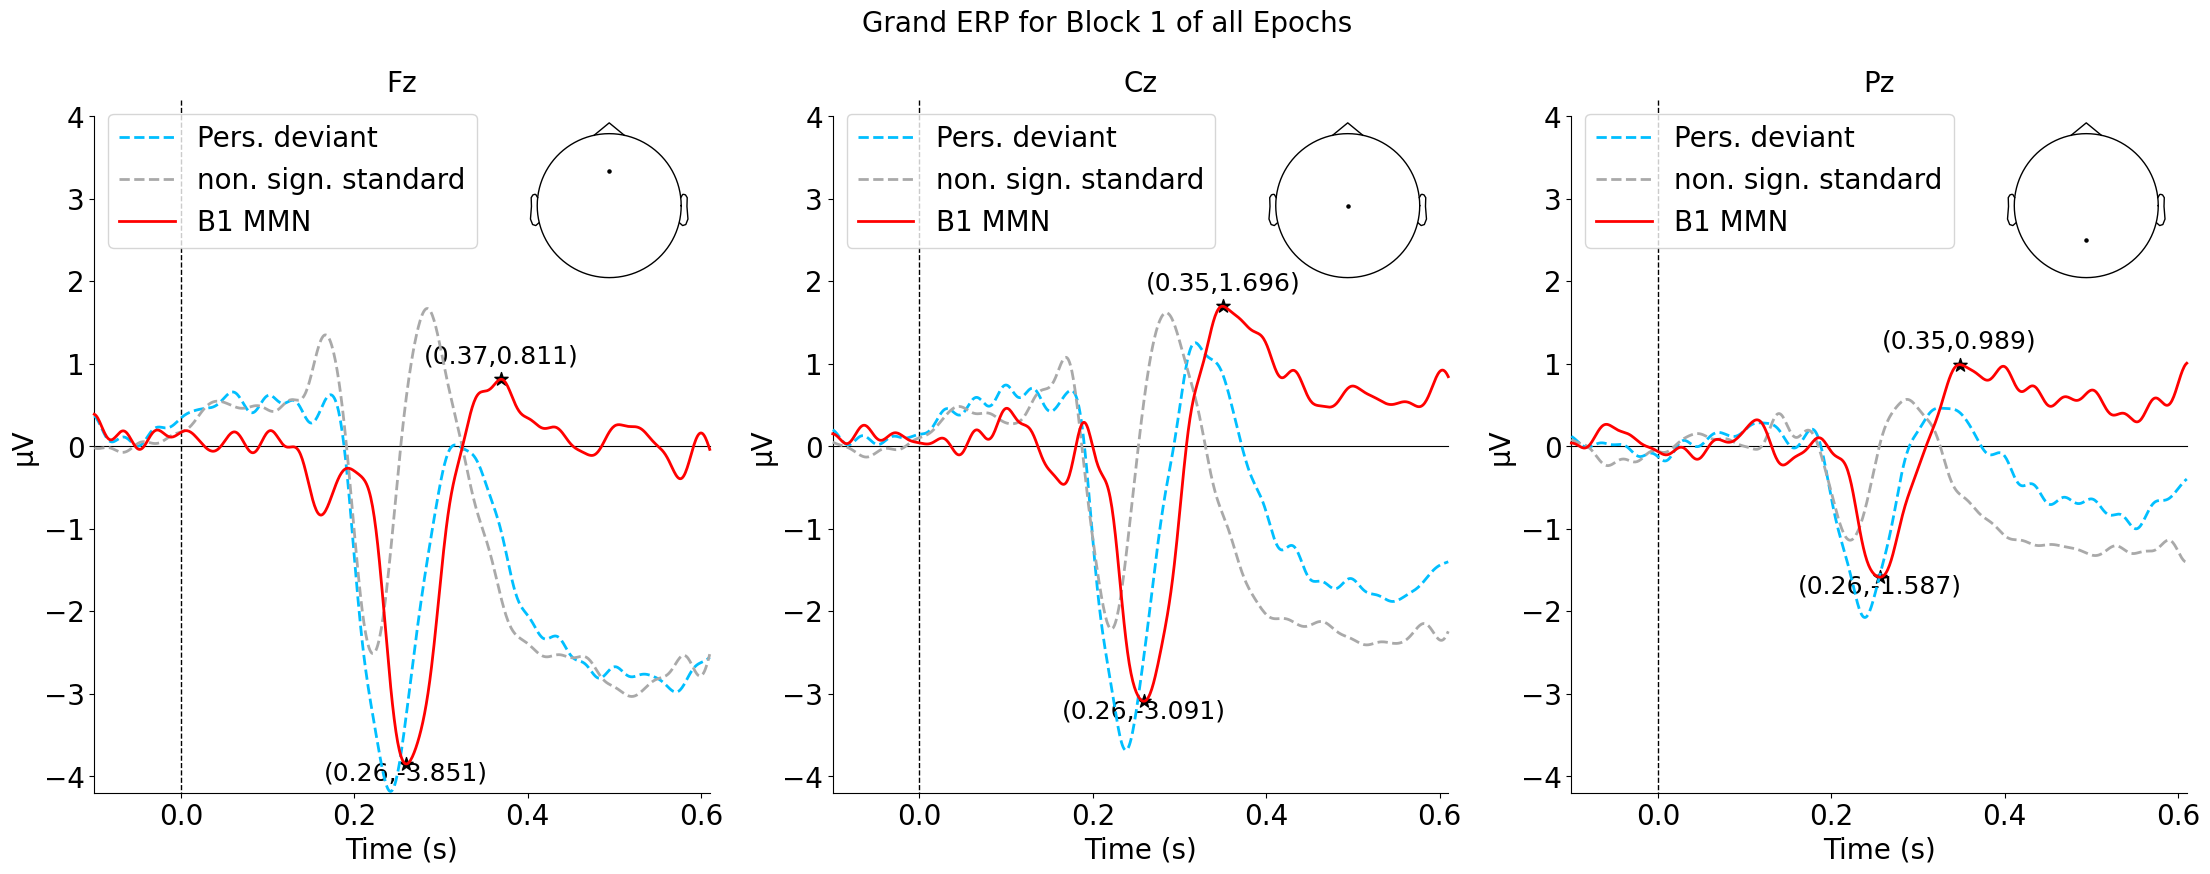

In [9]:
import mne
import matplotlib.pyplot as plt

# Assuming you have a dictionary of Evoked objects 'evokeds'
evokeds = {'Pers. deviant': B1_devi_eps,
           'non. sign. standard': B1_sta_eps,
           "B1 MMN" : B1_MMN_erp,
           }


# Define the start and end time for the window
start_time = -0.1  # Start of time window in seconds
end_time = 0.61    # End of time window in seconds

# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

laten_data = get_latency_amp_each_chn(evokeds_subset,tmin=.2,tmax =.4, channels=picks)
print(laten_data )
latency_amps.append(laten_data)


# Plot the evoked responses
fig,axs = plt.subplots(1,3,figsize=(27, 9))  # Create a figure and axis
picks  = ["Fz","Cz","Pz"]

stylesdict ={'Pers. deviant': {"linewidth": 2,"linestyle":'--'},
             'non. sign. standard': {"linewidth": 2,"linestyle":'--'},
             "B1 MMN": {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[0],ylim = dict(eeg=[-4.2, 4.2]),
                                   truncate_xaxis=False,show = False)
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[1],ylim = dict(eeg=[-4.2, 4.2]),
                                   truncate_xaxis=False,show= False)
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[2],ylim = dict(eeg=[-4.2, 4.2]),
                                   truncate_xaxis=False,show= False)

plot_pos_peak(laten_data["B1 MMN"]['Fz +(Latency (s),Amplitude (µV))'],axs[0])
plot_neg_peak(laten_data["B1 MMN"]['Fz- (Latency (s),Amplitude (µV))'],axs[0])
plot_pos_peak(laten_data["B1 MMN"]['Cz +(Latency (s),Amplitude (µV))'],axs[1])
plot_neg_peak(laten_data["B1 MMN"]['Cz- (Latency (s),Amplitude (µV))'],axs[1])
plot_pos_peak(laten_data["B1 MMN"]['Pz +(Latency (s),Amplitude (µV))'],axs[2])
plot_neg_peak(laten_data["B1 MMN"]['Pz- (Latency (s),Amplitude (µV))'],axs[2])
# Add an overall title for the whole plot
fig.suptitle('Grand ERP for Block 1 of all Epochs', fontsize=20)
plt.rcParams.update({
    'xtick.labelsize': 20,  # X-axis tick labels font size
    'ytick.labelsize': 20,  # Y-axis tick labels font size
    'axes.labelsize': 20,   # Axis label font size
    'axes.titlesize': 20,   # Title font size
    'legend.fontsize': 20,   # Legend font size
})
plt.show()

### BLock 2 ERP 

{'non. sign. deviant': {'Fz +(Latency (s),Amplitude (µV))': "('Na', 'Na')", 'Fz- (Latency (s),Amplitude (µV))': '(0.228, -3.938)', 'Cz +(Latency (s),Amplitude (µV))': '(0.363, 0.362)', 'Cz- (Latency (s),Amplitude (µV))': '(0.226, -3.422)', 'Pz +(Latency (s),Amplitude (µV))': '(0.363, 0.225)', 'Pz- (Latency (s),Amplitude (µV))': '(0.225, -1.694)'}, 'Pers. standard': {'Fz +(Latency (s),Amplitude (µV))': '(0.303, 1.636)', 'Fz- (Latency (s),Amplitude (µV))': '(0.4, -2.254)', 'Cz +(Latency (s),Amplitude (µV))': '(0.31, 1.834)', 'Cz- (Latency (s),Amplitude (µV))': '(0.4, -1.605)', 'Pz +(Latency (s),Amplitude (µV))': '(0.312, 0.737)', 'Pz- (Latency (s),Amplitude (µV))': '(0.4, -0.772)'}, 'B2 MMN': {'Fz +(Latency (s),Amplitude (µV))': '(0.381, 1.673)', 'Fz- (Latency (s),Amplitude (µV))': '(0.29, -3.312)', 'Cz +(Latency (s),Amplitude (µV))': '(0.377, 1.789)', 'Cz- (Latency (s),Amplitude (µV))': '(0.293, -2.505)', 'Pz +(Latency (s),Amplitude (µV))': '(0.367, 0.973)', 'Pz- (Latency (s),Amplitude 

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21180\1634151776.py:30: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21180\1634151776.py:33: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21180\1634151776.py:36: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],


combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


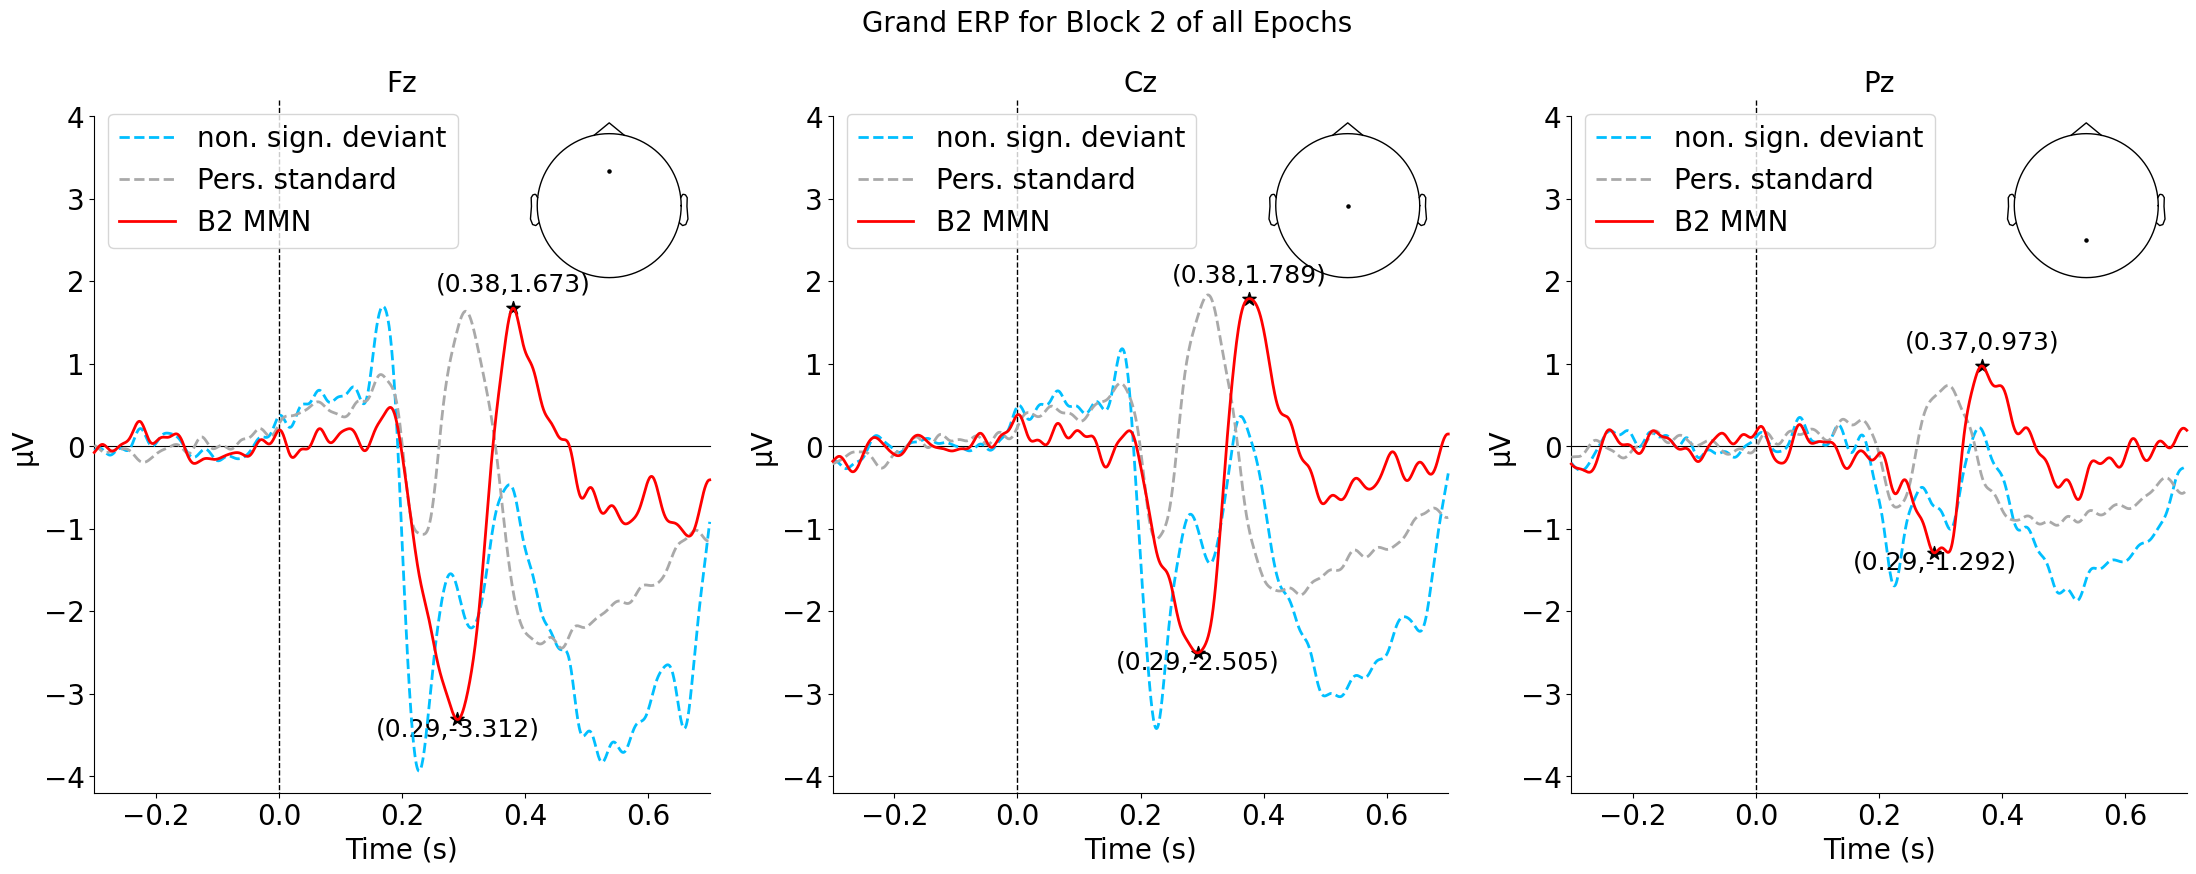

In [10]:
# Block 2 MMN
evokeds = {'non. sign. deviant': B2_devi_eps,
           'Pers. standard': B2_sta_eps,
           "B2 MMN" : B2_MMN_erp,
           }
# Define the start and end time for the window
start_time = -0.1  # Start of time window in seconds
end_time = 0.6    # End of time window in seconds

# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

laten_data = get_latency_amp_each_chn(evokeds_subset,tmin=.2,tmax =.4, channels=picks)
print(laten_data )
latency_amps.append(laten_data)

# Plot the evoked responses
fig,axs = plt.subplots(1,3,figsize=(27, 9))  # Create a figure and axis
picks  = ["Fz","Cz","Pz"]

stylesdict ={'non. sign. deviant': {"linewidth": 2,"linestyle":'--'},
             'Pers. standard': {"linewidth": 2,"linestyle":'--'},
            "B2 MMN": {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[0],ylim = dict(eeg=[-4.2, 4.2]),
                                   truncate_xaxis=False,show = False)
mne.viz.plot_compare_evokeds(evokeds, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[1],ylim = dict(eeg=[-4.2, 4.2]),
                                   truncate_xaxis=False,show= False)
mne.viz.plot_compare_evokeds(evokeds, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[2],ylim = dict(eeg=[-4.2, 4.2]),
                                   truncate_xaxis=False,show= False)

"""neg_peak = ast.literal_eval(laten_data["B2 MMN"]['Fz- (Latency (s),Amplitude (µV))'])
axs[0].scatter(neg_peak[0],neg_peak[1], color='black',marker = "*",s=100)
axs[0].text(neg_peak[0],neg_peak[1]-.2, f'({neg_peak[0]:.2f},{neg_peak[1]:.3f})', color='black', fontsize=18, ha='center')
pos_peak = ast.literal_eval(laten_data["B2 MMN"]['Fz +(Latency (s),Amplitude (µV))'])
axs[0].scatter(pos_peak[0],pos_peak[1], color='black',marker = "*",s=100)
axs[0].text(pos_peak[0],pos_peak[1]+.2, f'({pos_peak[0]:.2f},{pos_peak[1]:.3f})', color='black', fontsize=18, ha='center')"""
plot_pos_peak(laten_data["B2 MMN"]['Fz +(Latency (s),Amplitude (µV))'],axs[0])
plot_neg_peak(laten_data["B2 MMN"]['Fz- (Latency (s),Amplitude (µV))'],axs[0])
plot_pos_peak(laten_data["B2 MMN"]['Cz +(Latency (s),Amplitude (µV))'],axs[1])
plot_neg_peak(laten_data["B2 MMN"]['Cz- (Latency (s),Amplitude (µV))'],axs[1])
plot_pos_peak(laten_data["B2 MMN"]['Pz +(Latency (s),Amplitude (µV))'],axs[2])
plot_neg_peak(laten_data["B2 MMN"]['Pz- (Latency (s),Amplitude (µV))'],axs[2])
# Add an overall title for the whole plot
fig.suptitle('Grand ERP for Block 2 of all Epochs', fontsize=20)
plt.rcParams.update({
    'xtick.labelsize': 20,  # X-axis tick labels font size
    'ytick.labelsize': 20,  # Y-axis tick labels font size
    'axes.labelsize': 20,   # Axis label font size
    'axes.titlesize': 20,   # Title font size
    'legend.fontsize': 20,   # Legend font size
})
plt.show()

In [11]:
import pandas as pd
def latency_amps_to_df(dic):
    p_df = pd.DataFrame()
    for cond in dic.keys():
        df= pd.DataFrame.from_dict(dic[cond],orient='index')
        p_df = pd.concat([p_df, df],axis= 1)
    print(p_df.columns)
    p_df.columns = dic.keys()
    return p_df.T

latency_amps_to_df(latency_amps[0])


Index([0, 0, 0], dtype='int64')


,"Fz +(Latency (s),Amplitude (µV))","Fz- (Latency (s),Amplitude (µV))","Cz +(Latency (s),Amplitude (µV))","Cz- (Latency (s),Amplitude (µV))","Pz +(Latency (s),Amplitude (µV))","Pz- (Latency (s),Amplitude (µV))"
B1 MMN,"(0.369, 0.811)","(0.26, -3.851)","(0.35, 1.696)","(0.259, -3.091)","(0.348, 0.989)","(0.256, -1.587)"
B2 MMN,"(0.381, 1.673)","(0.29, -3.312)","(0.377, 1.789)","(0.293, -2.505)","(0.367, 0.973)","(0.29, -1.292)"
Pers. sign. ERP,"(0.314, 2.209)","(0.253, -1.282)","(0.316, 2.646)","(0.249, -1.293)","(0.317, 1.441)","(0.246, -1.059)"


In [12]:


peak_df = pd.DataFrame.from_dict(latency_amps[0],orient='index')
for dicts in latency_amps[1:]:
    #Convert the new data dictionary to a DataFrame
    df = pd.DataFrame.from_dict(dicts, orient='index')
    # Concatenate the existing DataFrame with the new DataFrame
    peak_df = pd.concat([peak_df, df])

peak_df

,"Fz +(Latency (s),Amplitude (µV))","Fz- (Latency (s),Amplitude (µV))","Cz +(Latency (s),Amplitude (µV))","Cz- (Latency (s),Amplitude (µV))","Pz +(Latency (s),Amplitude (µV))","Pz- (Latency (s),Amplitude (µV))"
B1 MMN,"(0.369, 0.811)","(0.26, -3.851)","(0.35, 1.696)","(0.259, -3.091)","(0.348, 0.989)","(0.256, -1.587)"
B2 MMN,"(0.381, 1.673)","(0.29, -3.312)","(0.377, 1.789)","(0.293, -2.505)","(0.367, 0.973)","(0.29, -1.292)"
Pers. sign. ERP,"(0.314, 2.209)","(0.253, -1.282)","(0.316, 2.646)","(0.249, -1.293)","(0.317, 1.441)","(0.246, -1.059)"
Pers. deviant,"(0.316, 0.015)","(0.242, -4.184)","(0.318, 1.254)","(0.238, -3.685)","(0.325, 0.462)","(0.239, -2.076)"
non. sign. standard,"(0.284, 1.669)","(0.221, -2.512)","(0.285, 1.617)","(0.221, -2.216)","(0.287, 0.568)","(0.222, -1.139)"
B1 MMN,"(0.369, 0.811)","(0.26, -3.851)","(0.35, 1.696)","(0.259, -3.091)","(0.348, 0.989)","(0.256, -1.587)"
non. sign. deviant,"('Na', 'Na')","(0.228, -3.938)","(0.363, 0.362)","(0.226, -3.422)","(0.363, 0.225)","(0.225, -1.694)"
Pers. standard,"(0.303, 1.636)","(0.4, -2.254)","(0.31, 1.834)","(0.4, -1.605)","(0.312, 0.737)","(0.4, -0.772)"
B2 MMN,"(0.381, 1.673)","(0.29, -3.312)","(0.377, 1.789)","(0.293, -2.505)","(0.367, 0.973)","(0.29, -1.292)"


### Personalised Deviant - Personalised standard 

{'Pers. deviant': {'Fz +(Latency (s),Amplitude (µV))': '(0.316, 0.015)', 'Fz- (Latency (s),Amplitude (µV))': '(0.242, -4.184)', 'Cz +(Latency (s),Amplitude (µV))': '(0.318, 1.254)', 'Cz- (Latency (s),Amplitude (µV))': '(0.238, -3.685)', 'Pz +(Latency (s),Amplitude (µV))': '(0.325, 0.462)', 'Pz- (Latency (s),Amplitude (µV))': '(0.239, -2.076)'}, 'Pers. standard': {'Fz +(Latency (s),Amplitude (µV))': '(0.303, 1.636)', 'Fz- (Latency (s),Amplitude (µV))': '(0.4, -2.254)', 'Cz +(Latency (s),Amplitude (µV))': '(0.31, 1.834)', 'Cz- (Latency (s),Amplitude (µV))': '(0.4, -1.605)', 'Pz +(Latency (s),Amplitude (µV))': '(0.312, 0.737)', 'Pz- (Latency (s),Amplitude (µV))': '(0.4, -0.772)'}, 'persoanl MMN': {'Fz +(Latency (s),Amplitude (µV))': '(0.398, 0.208)', 'Fz- (Latency (s),Amplitude (µV))': '(0.255, -3.258)', 'Cz +(Latency (s),Amplitude (µV))': '(0.393, 0.867)', 'Cz- (Latency (s),Amplitude (µV))': '(0.241, -2.699)', 'Pz +(Latency (s),Amplitude (µV))': '(0.4, 0.652)', 'Pz- (Latency (s),Amplitud

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21180\115005589.py:30: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21180\115005589.py:33: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21180\115005589.py:36: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],


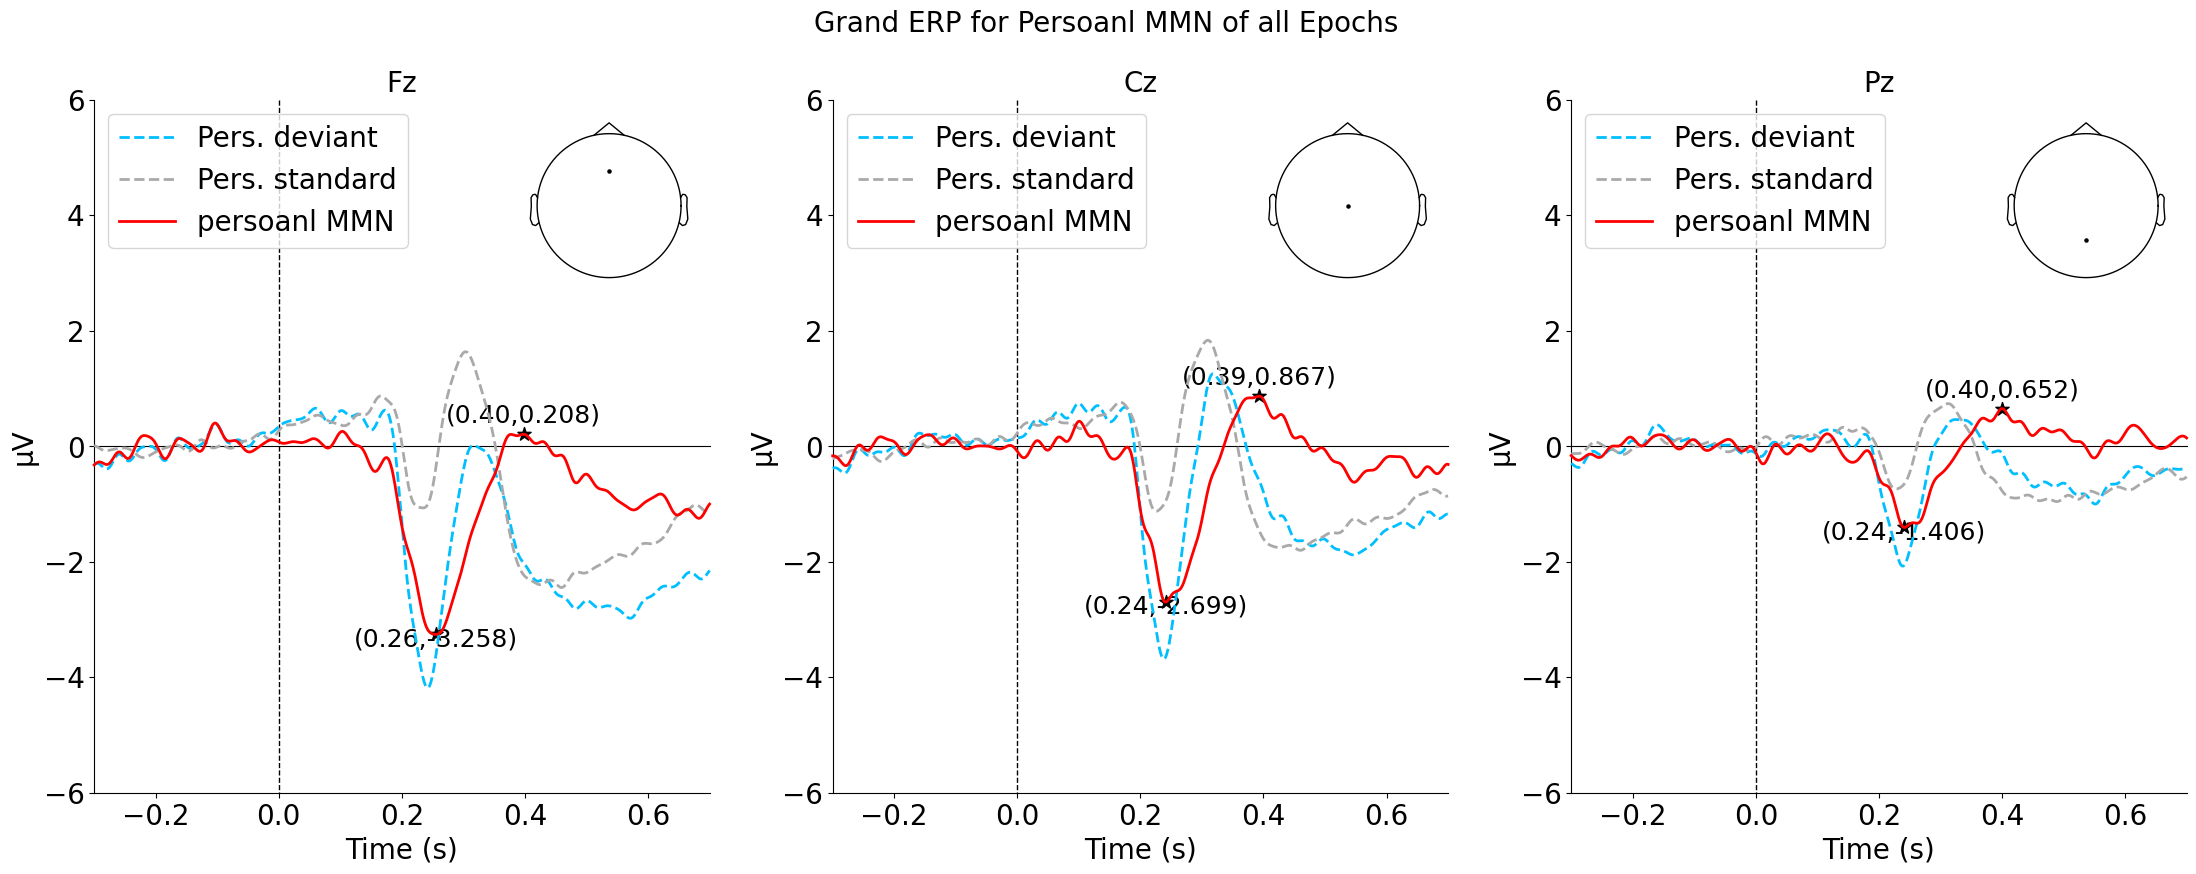

In [13]:

Personal_MMN_erp = mne.combine_evoked([B1_devi_eps,B2_sta_eps], weights=[1,-1])
evokeds = {'Pers. deviant': B1_devi_eps,
           'Pers. standard':B2_sta_eps,
           "persoanl MMN"  : Personal_MMN_erp,
           }
stylesdict ={'Pers. deviant': {"linewidth": 2,"linestyle":'--'},
             'Pers. standard': {"linewidth": 2,"linestyle":'--'},
             "persoanl MMN" : {"linewidth": 2,"linestyle":'solid'},
             }
# Define the start and end time for the window
start_time = -0.1  # Start of time window in seconds
end_time = 0.6    # End of time window in seconds

# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

laten_data = get_latency_amp_each_chn(evokeds_subset,tmin=.2,tmax =.4, channels=picks)
print(laten_data )
latency_amps.append(laten_data)

# Plot the evoked responses
fig,axs = plt.subplots(1,3,figsize=(27, 9))  # Create a figure and axis
picks  = ["Fz","Cz","Pz"]

mne.viz.plot_compare_evokeds(evokeds, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[0],ylim = dict(eeg=[-6, 6]),
                                   truncate_xaxis=False,show = False)
mne.viz.plot_compare_evokeds(evokeds, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[1],ylim = dict(eeg=[-6, 6]),
                                   truncate_xaxis=False,show= False)
mne.viz.plot_compare_evokeds(evokeds, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[2],ylim = dict(eeg=[-6, 6]),
                                   truncate_xaxis=False,show= False)

"""neg_peak = ast.literal_eval(laten_data["B2 MMN"]['Fz- (Latency (s),Amplitude (µV))'])
axs[0].scatter(neg_peak[0],neg_peak[1], color='black',marker = "*",s=100)
axs[0].text(neg_peak[0],neg_peak[1]-.2, f'({neg_peak[0]:.2f},{neg_peak[1]:.3f})', color='black', fontsize=18, ha='center')
pos_peak = ast.literal_eval(laten_data["B2 MMN"]['Fz +(Latency (s),Amplitude (µV))'])
axs[0].scatter(pos_peak[0],pos_peak[1], color='black',marker = "*",s=100)
axs[0].text(pos_peak[0],pos_peak[1]+.2, f'({pos_peak[0]:.2f},{pos_peak[1]:.3f})', color='black', fontsize=18, ha='center')"""
plot_pos_peak(laten_data["persoanl MMN"]['Fz +(Latency (s),Amplitude (µV))'],axs[0])
plot_neg_peak(laten_data["persoanl MMN"]['Fz- (Latency (s),Amplitude (µV))'],axs[0])
plot_pos_peak(laten_data["persoanl MMN"]['Cz +(Latency (s),Amplitude (µV))'],axs[1])
plot_neg_peak(laten_data["persoanl MMN"]['Cz- (Latency (s),Amplitude (µV))'],axs[1])
plot_pos_peak(laten_data["persoanl MMN"]['Pz +(Latency (s),Amplitude (µV))'],axs[2])
plot_neg_peak(laten_data["persoanl MMN"]['Pz- (Latency (s),Amplitude (µV))'],axs[2])
# Add an overall title for the whole plot
fig.suptitle('Grand ERP for Persoanl MMN of all Epochs', fontsize=20)
plt.rcParams.update({
    'xtick.labelsize': 20,  # X-axis tick labels font size
    'ytick.labelsize': 20,  # Y-axis tick labels font size
    'axes.labelsize': 20,   # Axis label font size
    'axes.titlesize': 20,   # Title font size
    'legend.fontsize': 20,   # Legend font size
})
plt.show()

### Non-significant deviant - Non-significant standard 

{'non. sign. deviant': {'Fz +(Latency (s),Amplitude (µV))': "('Na', 'Na')", 'Fz- (Latency (s),Amplitude (µV))': '(0.228, -3.938)', 'Cz +(Latency (s),Amplitude (µV))': '(0.363, 0.362)', 'Cz- (Latency (s),Amplitude (µV))': '(0.226, -3.422)', 'Pz +(Latency (s),Amplitude (µV))': '(0.363, 0.225)', 'Pz- (Latency (s),Amplitude (µV))': '(0.225, -1.694)'}, 'non. sign. standard': {'Fz +(Latency (s),Amplitude (µV))': '(0.284, 1.669)', 'Fz- (Latency (s),Amplitude (µV))': '(0.221, -2.512)', 'Cz +(Latency (s),Amplitude (µV))': '(0.285, 1.617)', 'Cz- (Latency (s),Amplitude (µV))': '(0.221, -2.216)', 'Pz +(Latency (s),Amplitude (µV))': '(0.287, 0.568)', 'Pz- (Latency (s),Amplitude (µV))': '(0.222, -1.139)'}, 'non. sign. MMN': {'Fz +(Latency (s),Amplitude (µV))': '(0.381, 1.673)', 'Fz- (Latency (s),Amplitude (µV))': '(0.29, -3.312)', 'Cz +(Latency (s),Amplitude (µV))': '(0.377, 1.789)', 'Cz- (Latency (s),Amplitude (µV))': '(0.293, -2.505)', 'Pz +(Latency (s),Amplitude (µV))': '(0.367, 0.973)', 'Pz- (La

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21180\1834414450.py:32: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21180\1834414450.py:35: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21180\1834414450.py:38: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],


combining channels using "mean"
combining channels using "mean"


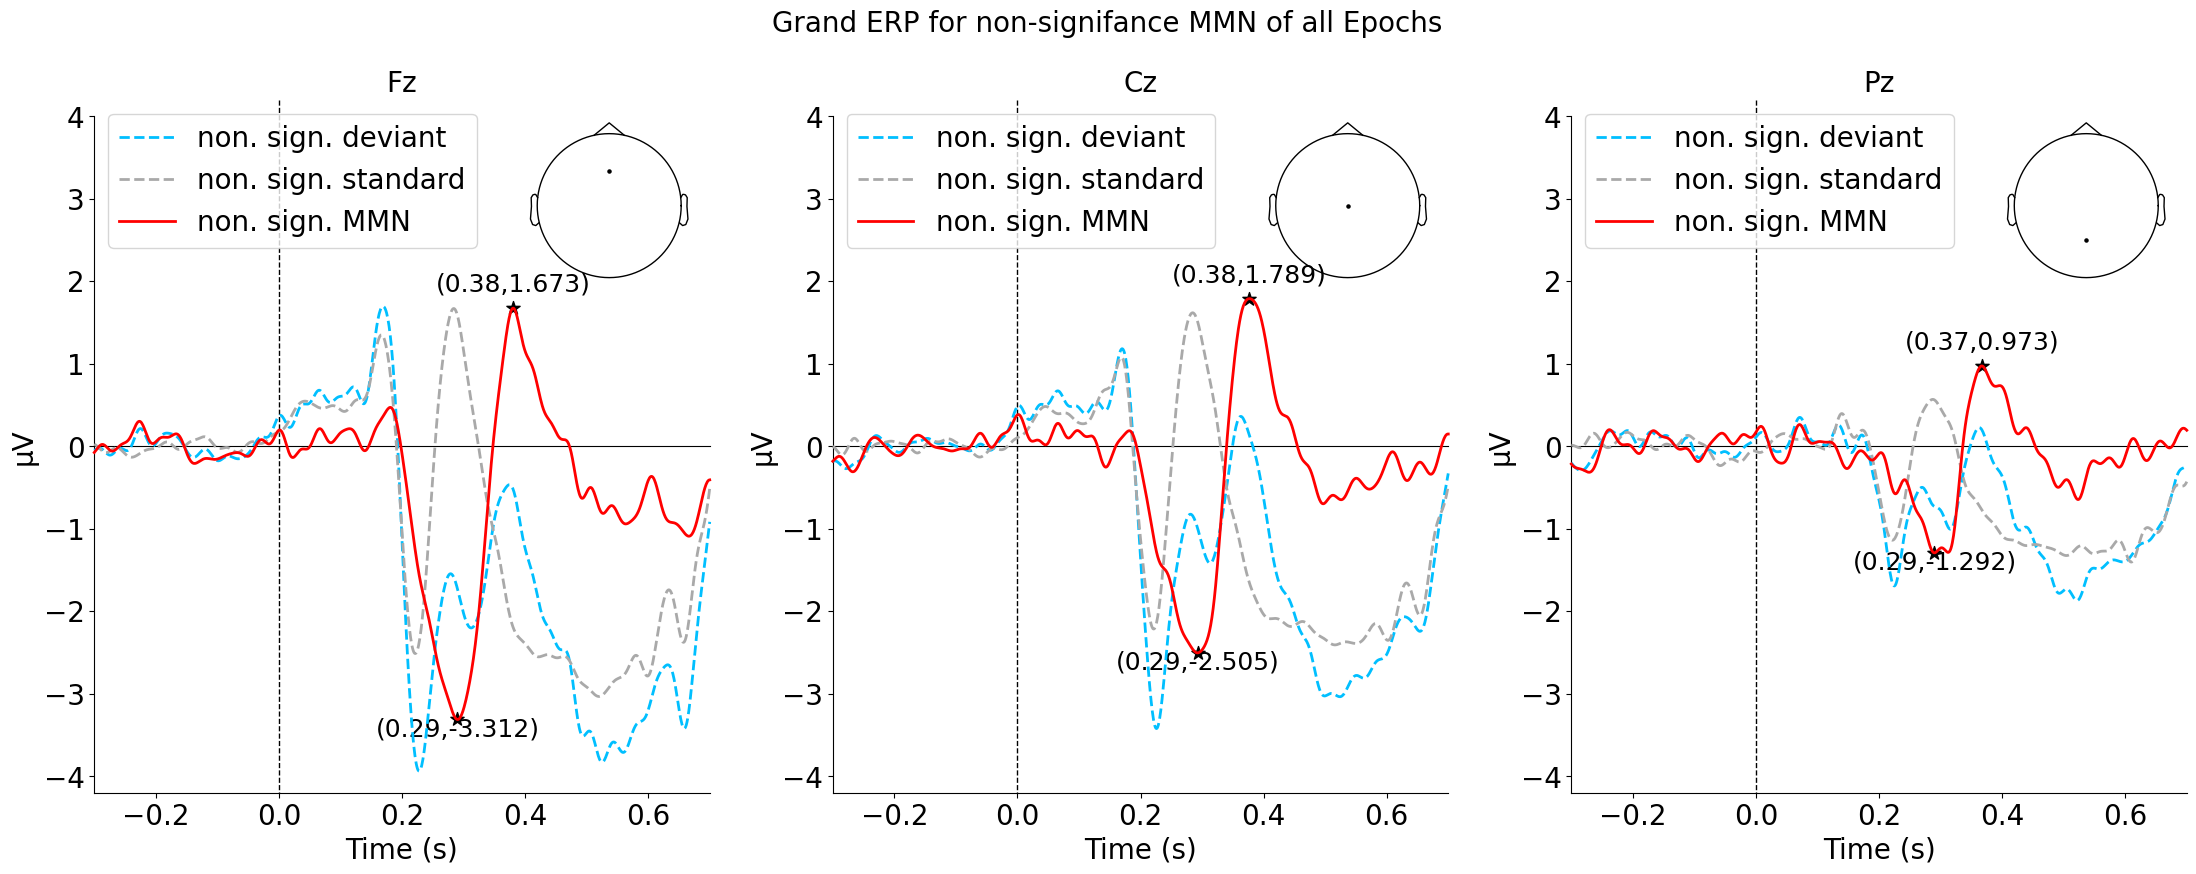

In [14]:

non_sign_MMN_erp = mne.combine_evoked([B2_devi_eps,B1_sta_eps], weights=[1,-1])

# ### Low addiction score 
evokeds = {'non. sign. deviant': B2_devi_eps,
           'non. sign. standard':B1_sta_eps,
           "non. sign. MMN"  : non_sign_MMN_erp,
           }
stylesdict ={'non. sign. deviant': {"linewidth": 2,"linestyle":'--'},
             'non. sign. standard': {"linewidth": 2,"linestyle":'--'},
             "non. sign. MMN" : {"linewidth": 2,"linestyle":'solid'},
             }
# Define the start and end time for the window
start_time = -0.1  # Start of time window in seconds
end_time = 0.6    # End of time window in seconds

# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

laten_data = get_latency_amp_each_chn(evokeds_subset,tmin=.2,tmax =.4, channels=picks)
print(laten_data )
latency_amps.append(laten_data)

# Plot the evoked responses
fig,axs = plt.subplots(1,3,figsize=(27, 9))  # Create a figure and axis
picks  = ["Fz","Cz","Pz"]

mne.viz.plot_compare_evokeds(evokeds, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[0],ylim = dict(eeg=[-4.2, 4.2]),
                                   truncate_xaxis=False,show = False)
mne.viz.plot_compare_evokeds(evokeds, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[1],ylim = dict(eeg=[-4.2, 4.2]),
                                   truncate_xaxis=False,show= False)
mne.viz.plot_compare_evokeds(evokeds, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[2],ylim = dict(eeg=[-4.2, 4.2]),
                                   truncate_xaxis=False,show= False)

"""neg_peak = ast.literal_eval(laten_data["B2 MMN"]['Fz- (Latency (s),Amplitude (µV))'])
axs[0].scatter(neg_peak[0],neg_peak[1], color='black',marker = "*",s=100)
axs[0].text(neg_peak[0],neg_peak[1]-.2, f'({neg_peak[0]:.2f},{neg_peak[1]:.3f})', color='black', fontsize=18, ha='center')
pos_peak = ast.literal_eval(laten_data["B2 MMN"]['Fz +(Latency (s),Amplitude (µV))'])
axs[0].scatter(pos_peak[0],pos_peak[1], color='black',marker = "*",s=100)
axs[0].text(pos_peak[0],pos_peak[1]+.2, f'({pos_peak[0]:.2f},{pos_peak[1]:.3f})', color='black', fontsize=18, ha='center')"""
plot_pos_peak(laten_data["non. sign. MMN"]['Fz +(Latency (s),Amplitude (µV))'],axs[0])
plot_neg_peak(laten_data["non. sign. MMN"]['Fz- (Latency (s),Amplitude (µV))'],axs[0])
plot_pos_peak(laten_data["non. sign. MMN"]['Cz +(Latency (s),Amplitude (µV))'],axs[1])
plot_neg_peak(laten_data["non. sign. MMN"]['Cz- (Latency (s),Amplitude (µV))'],axs[1])
plot_pos_peak(laten_data["non. sign. MMN"]['Pz +(Latency (s),Amplitude (µV))'],axs[2])
plot_neg_peak(laten_data["non. sign. MMN"]['Pz- (Latency (s),Amplitude (µV))'],axs[2])
# Add an overall title for the whole plot
fig.suptitle('Grand ERP for non-signifance MMN of all Epochs', fontsize=20)
plt.rcParams.update({
    'xtick.labelsize': 20,  # X-axis tick labels font size
    'ytick.labelsize': 20,  # Y-axis tick labels font size
    'axes.labelsize': 20,   # Axis label font size
    'axes.titlesize': 20,   # Title font size
    'legend.fontsize': 20,   # Legend font size
})
plt.show()

In [15]:
# ### Personalized siginificant ERP for all the categories
evokeds = {'PS deviant': B1_devi_eps,
           'Non Ps deviant': B2_devi_eps,
           }

# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

# Plot the evoked responses
fig,axs = plt.subplots(1, 3, figsize=(20, 7),  sharey=True, gridspec_kw={'width_ratios': [1, 1,1]},dpi =1000)

stylesdict ={'PS deviant': {"linewidth": 3,"linestyle":'solid'},
             'Non Ps deviant' : {"linewidth": 3,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes=axs[1],ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,title='Deviant')

# ### B1 MMN  for all the categories
evokeds = {'PS std':B2_sta_eps,
           'Non PS std': B1_sta_eps,
                      }
# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop



stylesdict ={'PS std': {"linewidth": 3,"linestyle":'solid'},
             'Non PS std' : {"linewidth": 3,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes=axs[0],ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,title='Standard')


# ### B1 MMN  for all the categories
evokeds = {'PS MMN':Personal_MMN_erp,
           'Non PS MMN': non_sign_MMN_erp,
                      }
# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop



stylesdict ={'PS MMN': {"linewidth": 3,"linestyle":'solid'},
             'Non PS MMN' : {"linewidth": 3,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes=axs[2],ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,title='MMN')

# Add an overall title for the whole plot
#fig.suptitle('Low, Medium and High smartphone user  ', fontsize=30)
axs[0].text(0.75, 0.40, f"PS", transform=axs[0].transAxes, fontsize=30, color='deepskyblue')
axs[0].text( 0.75,0.20, f"Non-PS", transform=axs[0].transAxes, fontsize=30, color='darkorange')
# Add an arrow pointing to a specific point
axs[0].annotate(
    '',  # Text for the annotation
    xy=(210,-5),  # Point to annotate (x, y)
    xytext=(250, -4.5),  # Position of the text (x, y)
    arrowprops=dict(facecolor='black', arrowstyle='<-',linewidth  = 5)  # Arrow properties
)
axs[2].annotate(
    '',  # Text for the annotation
    xy=(160,4),  # Point to annotate (x, y)
    xytext=(200, 3.5),  # Position of the text (x, y)
    arrowprops=dict(facecolor='black', arrowstyle='<-',linewidth  = 5)  # Arrow properties
)
plt.tight_layout(rect=[0, 0, 1, 0.98])
axes = fig.axes  # List of subplot axes
axes[0].set_ylabel('Evoked Responses (µV)')
for ax in axes[1:]:  # Skip the first subplot (index 0)
    ax.set_ylabel('')
plt.rcParams.update({
    'xtick.labelsize': 25,  # X-axis tick labels font size
    'ytick.labelsize': 25,  # Y-axis tick labels font size
    'axes.labelsize': 25,   # Axis label font size
    'axes.titlesize': 25,   # Title font size 
    'legend.fontsize': 25,   # Legend font size
})
plt.show()

combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21180\2981479417.py:20: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21180\2981479417.py:41: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21180\2981479417.py:63: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,


combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21180\973626230.py:20: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21180\973626230.py:41: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21180\973626230.py:63: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,


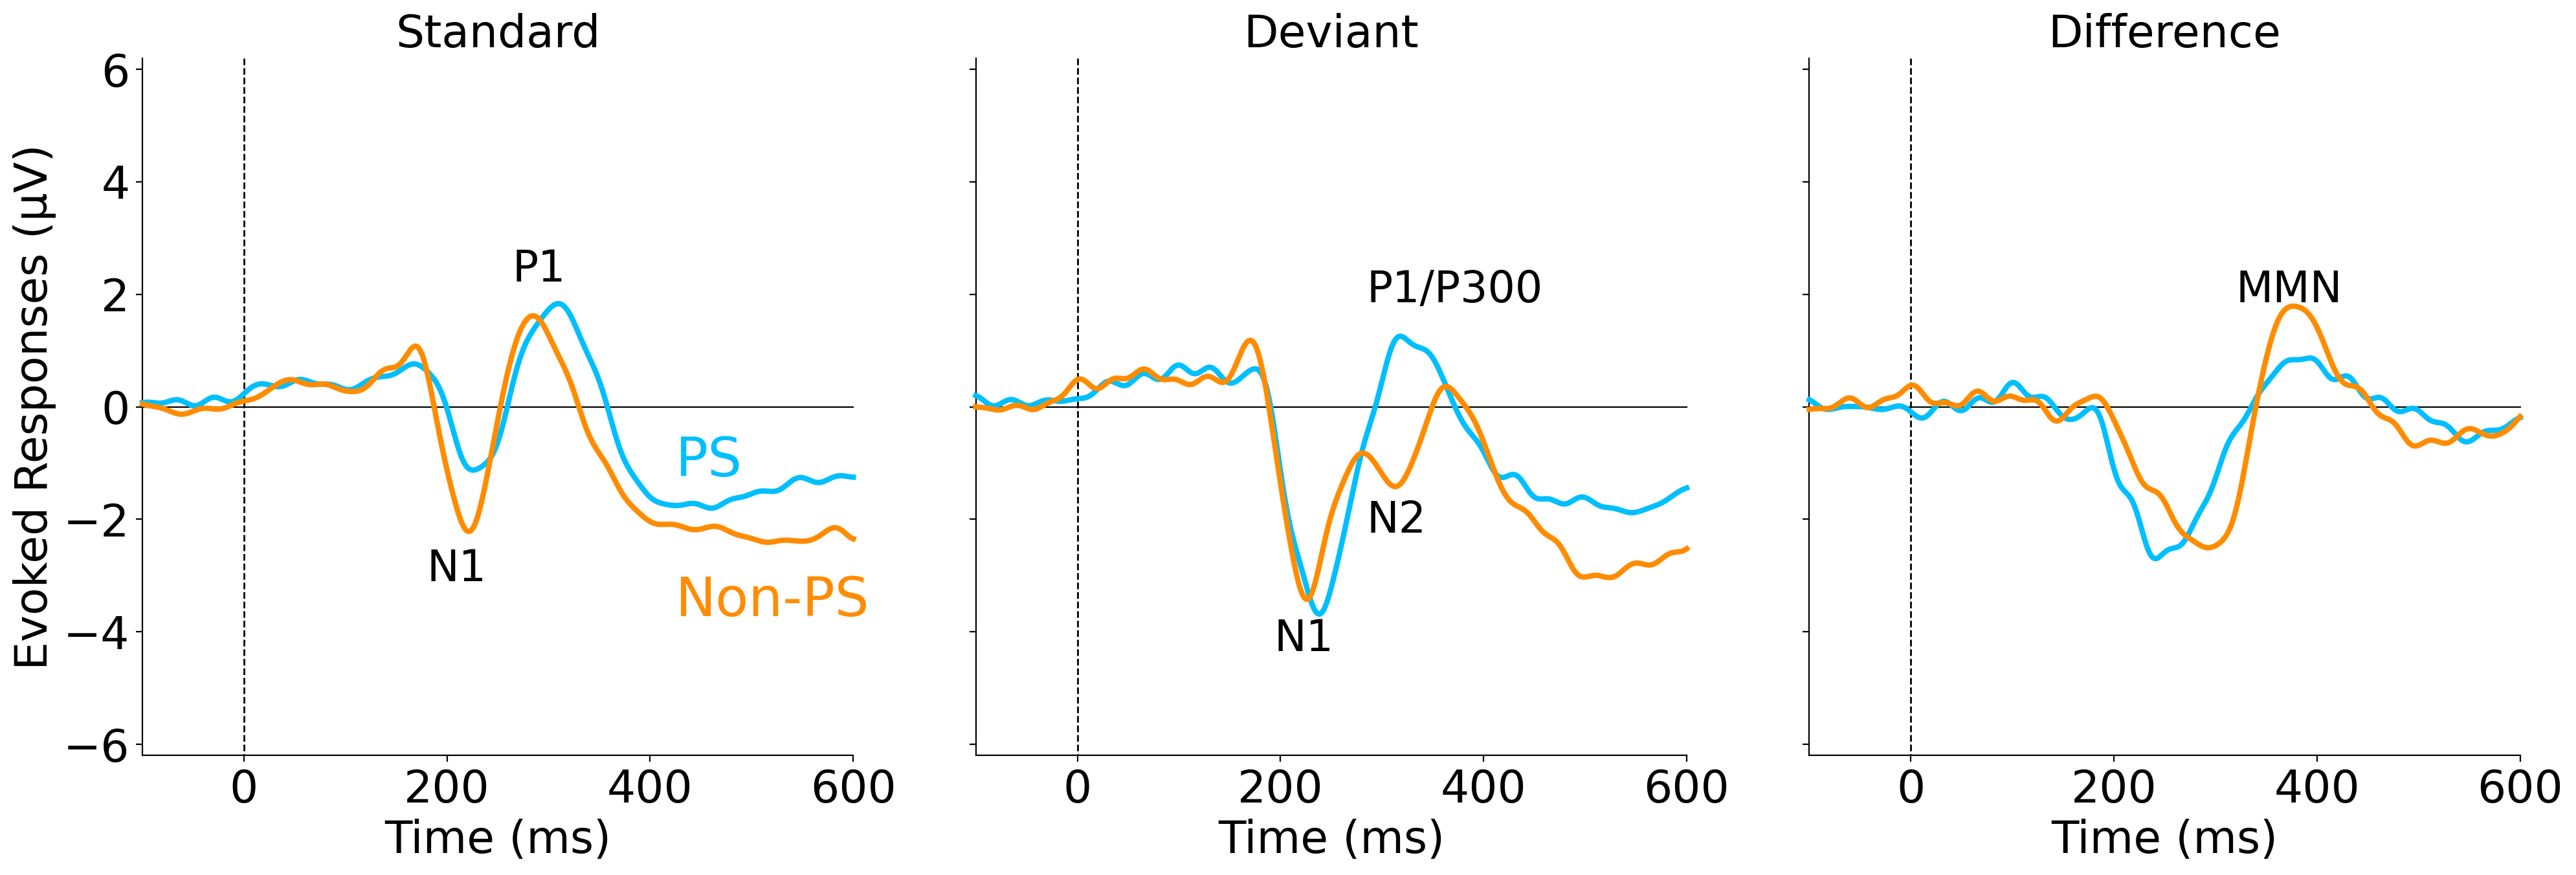

In [78]:
# ### Personalized siginificant ERP for all the categories
evokeds = {'PS deviant': B1_devi_eps,
           'Non Ps deviant': B2_devi_eps,
           }

# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

# Plot the evoked responses
fig,axs = plt.subplots(1, 3, figsize=(20, 7),  sharey=True, gridspec_kw={'width_ratios': [1, 1,1]},dpi =200)

stylesdict ={'PS deviant': {"linewidth": 3,"linestyle":'solid'},
             'Non Ps deviant' : {"linewidth": 3,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes=axs[1],ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,title='Deviant')

# ### B1 MMN  for all the categories
evokeds = {'PS std':B2_sta_eps,
           'Non PS std': B1_sta_eps,
                      }
# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop



stylesdict ={'PS std': {"linewidth": 3,"linestyle":'solid'},
             'Non PS std' : {"linewidth": 3,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes=axs[0],ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,title='Standard')


# ### B1 MMN  for all the categories
evokeds = {'PS MMN':Personal_MMN_erp,
           'Non PS MMN': non_sign_MMN_erp,
                      }
# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop



stylesdict ={'PS MMN': {"linewidth": 3,"linestyle":'solid'},
             'Non PS MMN' : {"linewidth": 3,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes=axs[2],ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,title='Difference')

# Add an overall title for the whole plot
#fig.suptitle('Low, Medium and High smartphone user  ', fontsize=30)
axs[0].text(0.75, 0.40, f"PS", transform=axs[0].transAxes, fontsize=30, color='deepskyblue')
axs[0].text( 0.75,0.20, f"Non-PS", transform=axs[0].transAxes, fontsize=30, color='darkorange')
# Add an arrow pointing to a specific point
axs[0].text(0.40, 0.25, f"N1", transform=axs[0].transAxes, fontsize=24, color='black')
axs[0].text( 0.52,0.68, f"P1", transform=axs[0].transAxes, fontsize=24, color='black')

# Add an arrow pointing to a specific point
axs[1].text(0.42, 0.15, f"N1", transform=axs[1].transAxes, fontsize=24, color='black')
axs[1].text(0.55, 0.32, f"N2", transform=axs[1].transAxes, fontsize=24, color='black')
axs[1].text( 0.55,0.65, f"P1/P300", transform=axs[1].transAxes, fontsize=24, color='black')
axs[2].text( 0.60,0.65, f"MMN", transform=axs[2].transAxes, fontsize=24, color='black')
plt.tight_layout(rect=[0, 0, 1, 0.98])
axes = fig.axes  # List of subplot axes
axes[0].set_ylabel('Evoked Responses (µV)')
for ax in axes[1:]:  # Skip the first subplot (index 0)
    ax.set_ylabel('')
plt.rcParams.update({
    'xtick.labelsize': 25,  # X-axis tick labels font size
    'ytick.labelsize': 25,  # Y-axis tick labels font size
    'axes.labelsize': 25,   # Axis label font size
    'axes.titlesize': 25,   # Title font size 
    'legend.fontsize': 25,   # Legend font size
})
plt.show()

combining channels using "mean"


combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21180\1196054258.py:21: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['darkorange'],show_sensors=False,legend=False,
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21180\1196054258.py:46: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21180\1196054258.py:73: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange','red'],show_sensors=False,legend=False,


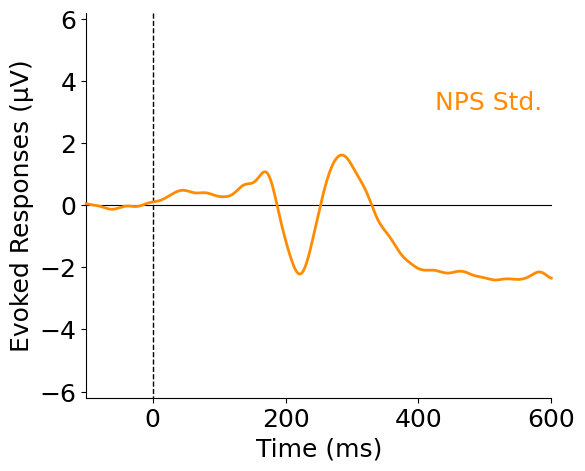

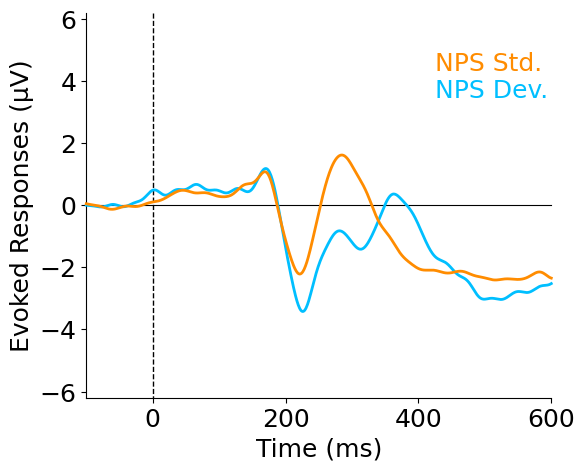

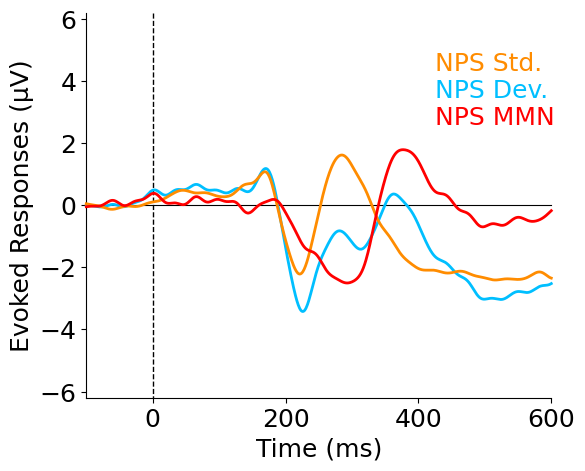

In [71]:
# ### Personalized siginificant ERP for all the categories
evokeds = {
    'Non PS std':B1_sta_eps,
           
           }

# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)

stylesdict ={
             'Non PS std' : {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['darkorange'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='')
axs.text( 0.75,0.750, f"NPS Std.", transform=axs.transAxes, fontsize=18, color='darkorange')
axs.set_ylabel('Evoked Responses (µV)')
 
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)
evokeds = {
           'Non Ps deviant': B2_devi_eps,
           'Non PS std':B1_sta_eps,
                      }
# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop



stylesdict ={'Non Ps deviant': {"linewidth": 2,"linestyle":'solid'},
             'Non PS std' : {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='')
axs.text( 0.75,0.85, f"NPS Std.", transform=axs.transAxes, fontsize=18, color='darkorange')
axs.text( 0.75,0.78, f"NPS Dev.", transform=axs.transAxes, fontsize=18, color='deepskyblue')
axs.set_ylabel('Evoked Responses (µV)')
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)
evokeds = {
           'Non Ps deviant': B2_devi_eps,
           'Non PS std':B1_sta_eps,
           'Non PS MMN': non_sign_MMN_erp,
                      }
# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop



stylesdict ={'Non Ps deviant': {"linewidth": 2,"linestyle":'solid'},
             'Non PS std' : {"linewidth": 2,"linestyle":'solid'},
             'Non PS MMN' :  {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange','red'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes=axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,title='')
axs.text( 0.75,0.85, f"NPS Std.", transform=axs.transAxes, fontsize=18, color='darkorange')
axs.text( 0.75,0.78, f"NPS Dev.", transform=axs.transAxes, fontsize=18, color='deepskyblue')
axs.text( 0.75,0.71, f"NPS MMN", transform=axs.transAxes, fontsize=18, color='red')
axs.set_ylabel('Evoked Responses (µV)')
plt.rcParams.update({
    'xtick.labelsize': 18,  # X-axis tick labels font size
    'ytick.labelsize': 18,  # Y-axis tick labels font size
    'axes.labelsize': 18,   # Axis label font size
    'axes.titlesize': 18,   # Title font size 
    'legend.fontsize': 18,   # Legend font size
})
plt.show( )# export it 

combining channels using "mean"


combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21180\1321200263.py:21: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['darkorange'],show_sensors=False,legend=False,
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21180\1321200263.py:46: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21180\1321200263.py:73: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange','red'],show_sensors=False,legend=False,


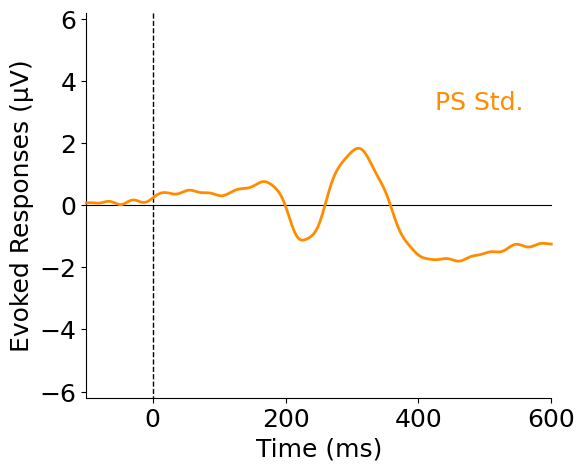

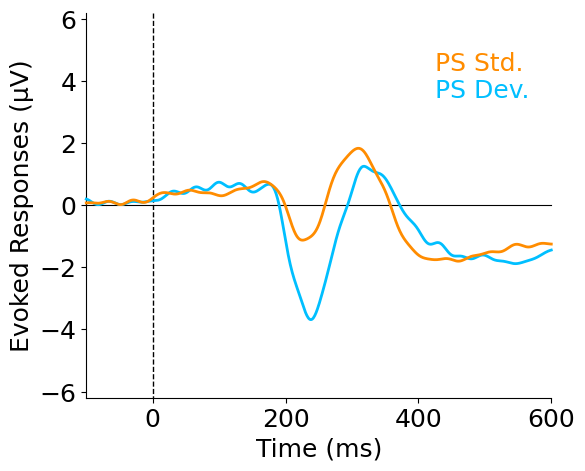

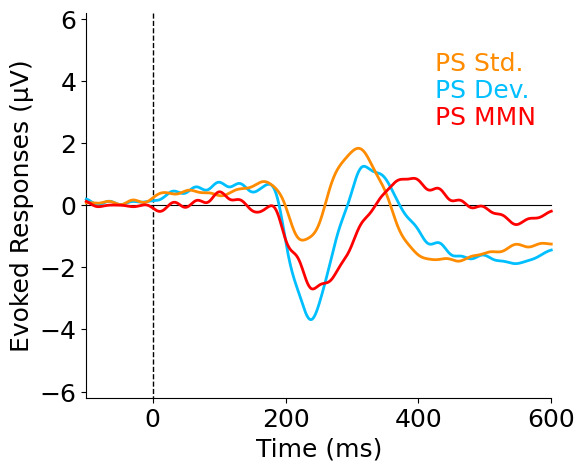

In [74]:
# ### Personalized siginificant ERP for all the categories
evokeds = {
    'PS std':B2_sta_eps,
           
           }

# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)

stylesdict ={
             'PS std' : {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['darkorange'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='')
axs.text( 0.75,0.750, f"PS Std.", transform=axs.transAxes, fontsize=18, color='darkorange')
axs.set_ylabel('Evoked Responses (µV)')
 
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)
evokeds = {
           'Ps deviant': B1_devi_eps,
           'PS std':B2_sta_eps,
                      }
# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop



stylesdict ={'Ps deviant': {"linewidth": 2,"linestyle":'solid'},
             'PS std' : {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='')
axs.text( 0.75,0.85, f"PS Std.", transform=axs.transAxes, fontsize=18, color='darkorange')
axs.text( 0.75,0.78, f"PS Dev.", transform=axs.transAxes, fontsize=18, color='deepskyblue')
axs.set_ylabel('Evoked Responses (µV)')
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)
evokeds = {
           'Ps deviant': B1_devi_eps,
           'PS std':B2_sta_eps,
           'PS MMN': Personal_MMN_erp,
                      }
# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop



stylesdict ={'Ps deviant': {"linewidth": 2,"linestyle":'solid'},
             'PS std' : {"linewidth": 2,"linestyle":'solid'},
             'PS MMN' :  {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange','red'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes=axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,title='')
axs.text( 0.75,0.85, f"PS Std.", transform=axs.transAxes, fontsize=18, color='darkorange')
axs.text( 0.75,0.78, f"PS Dev.", transform=axs.transAxes, fontsize=18, color='deepskyblue')
axs.text( 0.75,0.71, f"PS MMN", transform=axs.transAxes, fontsize=18, color='red')
axs.set_ylabel('Evoked Responses (µV)')
plt.rcParams.update({
    'xtick.labelsize': 18,  # X-axis tick labels font size
    'ytick.labelsize': 18,  # Y-axis tick labels font size
    'axes.labelsize': 18,   # Axis label font size
    'axes.titlesize': 18,   # Title font size 
    'legend.fontsize': 18,   # Legend font size
})
plt.show( )# export it 

combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21180\1180772074.py:21: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['darkorange'],show_sensors=False,legend=False,
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_21180\1180772074.py:46: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,


Text(0, 0.5, 'Evoked Responses (µV)')

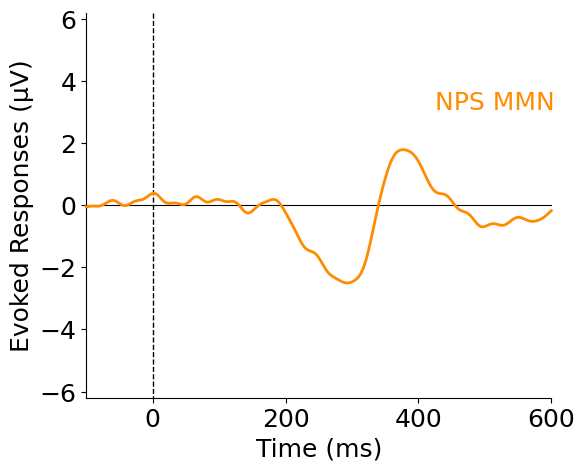

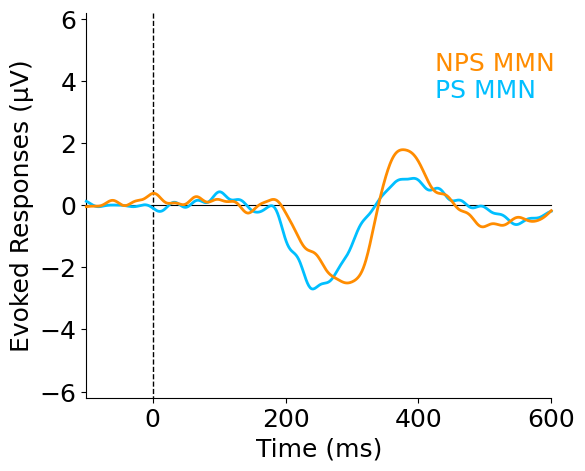

In [75]:
# ### Personalized siginificant ERP for all the categories
evokeds = {
    'NPS MMN':non_sign_MMN_erp,
           
           }

# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)

stylesdict ={
             'NPS MMN' : {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['darkorange'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='')
axs.text( 0.75,0.750, f"NPS MMN", transform=axs.transAxes, fontsize=18, color='darkorange')
axs.set_ylabel('Evoked Responses (µV)')
 
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)
evokeds = {
    "PS MMN" : Personal_MMN_erp,
    'NPS MMN':non_sign_MMN_erp,
           }
# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop



stylesdict ={"PS MMN": {"linewidth": 2,"linestyle":'solid'},
             'NPS MMN' : {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='')
axs.text( 0.75,0.85, f"NPS MMN", transform=axs.transAxes, fontsize=18, color='darkorange')
axs.text( 0.75,0.78, f"PS MMN", transform=axs.transAxes, fontsize=18, color='deepskyblue')
axs.set_ylabel('Evoked Responses (µV)')
# Plot the evoked responses